# Data-Driven Building Temperature Prediction

This notebook investigates short-term indoor-temperature
prediction using machine learning.

A Random Forest regression model is trained using synthetic
building operating data generated by the reduced-order thermal
model.

The model predicts the indoor temperature at the next hourly
timestep using:

- current indoor temperature
- building thermal mass temperature
- outdoor temperature
- solar gains
- internal gains
- HVAC thermal input

A persistence model is also used as a baseline for comparison.

In [6]:
import sys
import os

sys.path.append(
    os.path.abspath("../src")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulate import run_baseline_simulation

from sklearn.ensemble import RandomForestRegressor

from evaluation import (
    calculate_prediction_metrics
)

In [7]:
df = run_baseline_simulation(
    n_steps=168
)

df.head()

,hour,T_out,Q_solar,Q_internal,Q_HVAC,P_electric,T_in,T_mass,energy_kWh
0,0,2.457076,0.0,392.168105,0.0,0.000000,21.000000,21.000000,0.000000
1,1,0.712617,0.0,397.961874,0.0,0.000000,20.614816,21.000000,0.000000
2,2,4.197474,0.0,367.260615,0.0,0.000000,20.190416,20.999445,0.000000
3,3,5.753993,0.0,422.303610,5000.0,1728.571429,19.890748,20.998280,1.728571
4,4,3.073447,0.0,377.250826,0.0,0.000000,23.301831,20.996685,0.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   hour        168 non-null    int64  
 1   T_out       168 non-null    float64
 2   Q_solar     168 non-null    float64
 3   Q_internal  168 non-null    float64
 4   Q_HVAC      168 non-null    float64
 5   P_electric  168 non-null    float64
 6   T_in        168 non-null    float64
 7   T_mass      168 non-null    float64
 8   energy_kWh  168 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 11.9 KB


In [9]:
df.describe()

,hour,T_out,Q_solar,Q_internal,Q_HVAC,P_electric,T_in,T_mass,energy_kWh
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,83.500000,9.920251,949.469264,676.191349,-958.333333,548.412698,22.763466,21.196919,0.548413
std,48.641546,5.804315,1164.724438,310.958508,2195.133885,778.105081,1.684976,0.111332,0.778105
min,0.000000,-0.126273,0.000000,271.667078,-4000.000000,0.000000,19.660578,20.996685,0.000000
25%,41.750000,4.446602,0.000000,390.469794,-4000.000000,0.000000,21.521259,21.116824,0.000000
50%,83.500000,10.239584,0.000000,473.323407,0.000000,0.000000,22.555885,21.199144,0.000000
75%,125.250000,14.962254,2121.320344,999.304182,0.000000,1633.333333,24.184262,21.286493,1.633333
max,167.000000,20.379301,3000.000000,1145.253358,5000.000000,1728.571429,26.087666,21.380734,1.728571


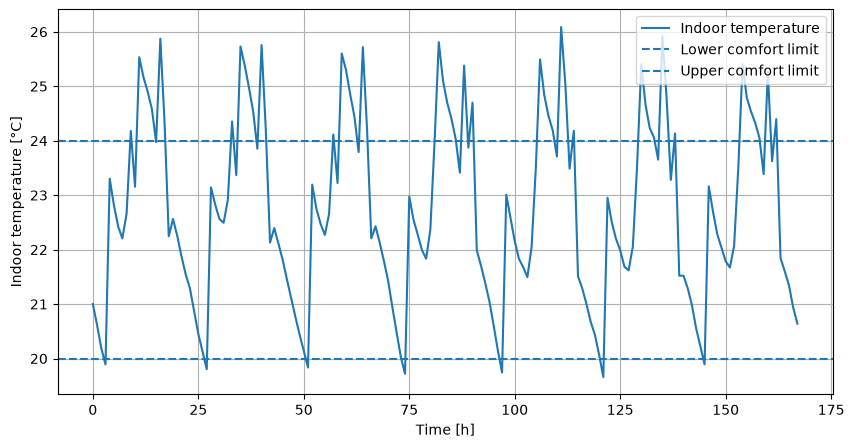

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["hour"],
    df["T_in"],
    label="Indoor temperature"
)

plt.axhline(
    20,
    linestyle="--",
    label="Lower comfort limit"
)

plt.axhline(
    24,
    linestyle="--",
    label="Upper comfort limit"
)

plt.xlabel("Time [h]")
plt.ylabel("Indoor temperature [°C]")

plt.legend()
plt.grid()

plt.show()

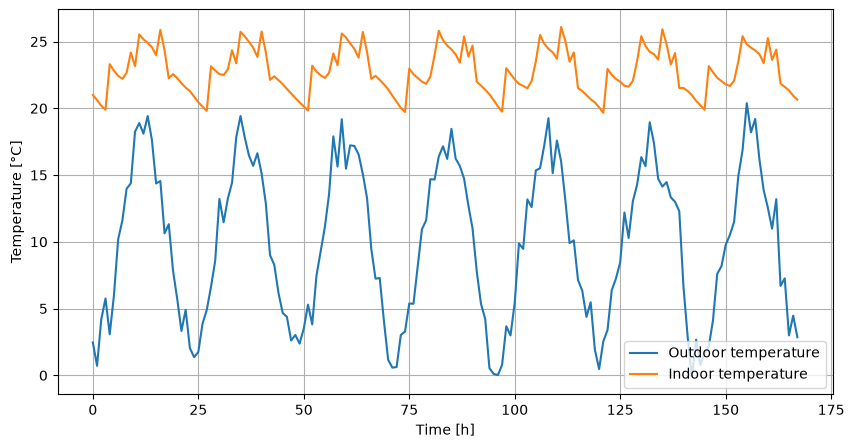

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["hour"],
    df["T_out"],
    label="Outdoor temperature"
)

plt.plot(
    df["hour"],
    df["T_in"],
    label="Indoor temperature"
)

plt.xlabel("Time [h]")
plt.ylabel("Temperature [°C]")

plt.legend()
plt.grid()

plt.show()

In [12]:
df["T_in_next"] = df["T_in"].shift(-1)

In [13]:
df.head()

,hour,T_out,Q_solar,Q_internal,Q_HVAC,P_electric,T_in,T_mass,energy_kWh,T_in_next
0,0,2.457076,0.0,392.168105,0.0,0.000000,21.000000,21.000000,0.000000,20.614816
1,1,0.712617,0.0,397.961874,0.0,0.000000,20.614816,21.000000,0.000000,20.190416
2,2,4.197474,0.0,367.260615,0.0,0.000000,20.190416,20.999445,0.000000,19.890748
3,3,5.753993,0.0,422.303610,5000.0,1728.571429,19.890748,20.998280,1.728571,23.301831
4,4,3.073447,0.0,377.250826,0.0,0.000000,23.301831,20.996685,0.000000,22.812036


In [14]:
df = df.dropna().reset_index(drop=True)

In [15]:
features = [
    "T_in",
    "T_mass",
    "T_out",
    "Q_solar",
    "Q_internal",
    "Q_HVAC",
]

In [16]:
X = df[features]

y = df["T_in_next"]

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (167, 6)
y shape: (167,)


In [18]:
split_index = int(
    len(df) * 0.8
)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [19]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=1
)

In [20]:
model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

In [22]:
predictions = model.predict(
    X_test
)

In [23]:
metrics = calculate_prediction_metrics(
    y_test,
    predictions
)

In [24]:
print("Prediction performance:")
print(
    f"MAE: {metrics['MAE']:.3f} °C"
)
print(
    f"RMSE: {metrics['RMSE']:.3f} °C"
)
print(
    f"Maximum error: "
    f"{metrics['Max Error']:.3f} °C"
)

Prediction performance:
MAE: 0.257 °C
RMSE: 0.392 °C
Maximum error: 1.255 °C


In [25]:
persistence_prediction = X_test["T_in"].values

In [26]:
persistence_metrics = (
    calculate_prediction_metrics(
        y_test,
        persistence_prediction
    )
)

In [27]:
print("Persistence baseline:")
print(
    f"MAE: "
    f"{persistence_metrics['MAE']:.3f} °C"
)
print(
    f"RMSE: "
    f"{persistence_metrics['RMSE']:.3f} °C"
)

Persistence baseline:
MAE: 0.852 °C
RMSE: 1.197 °C


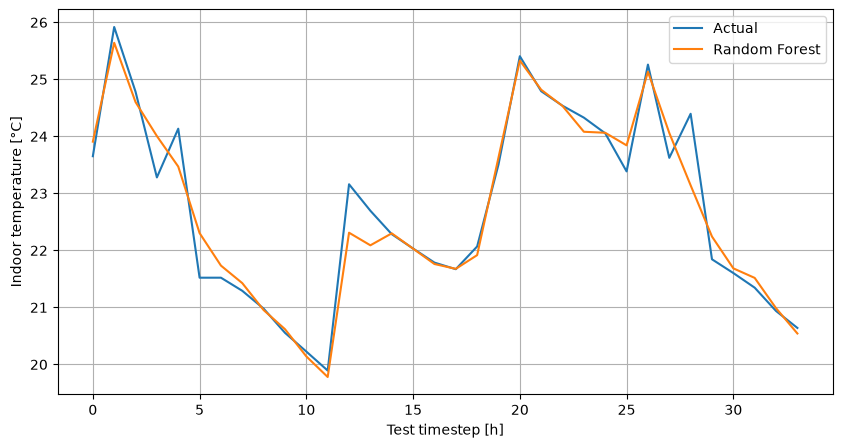

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    predictions,
    label="Random Forest"
)

plt.xlabel("Test timestep [h]")
plt.ylabel("Indoor temperature [°C]")

plt.legend()
plt.grid()

plt.savefig(
    "../figures/temperature_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()